In [1]:
%pip install python-dotenv pandas scikit-learn nltk pymorphy3 gensim

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

df = pd.read_json('https://huggingface.co/datasets/blinoff/restaurants_reviews/resolve/main/restaurants_reviews.jsonl', lines=True)

In [3]:
df.info()
print(df.head())
df['general'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 47139 entries, 0 to 47138
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  47139 non-null  int64 
 1   general    47139 non-null  int64 
 2   food       47139 non-null  object
 3   interior   47139 non-null  object
 4   service    47139 non-null  object
 5   text       47139 non-null  str   
dtypes: int64(2), object(3), str(1)
memory usage: 2.2+ MB
   review_id  general food interior service  \
0          0        0   10       10      10   
1          1        0    9       10       9   
2          2        0    9       10      10   
3          3        0    -        5      10   
4          4        0    7       10      10   

                                                text  
0  Вытянули меня сегодня в город и раз уж была в ...  
1  проводили корпоратив на 60 чел. в этот - уже т...  
2  Был в Гостях с женой один раз и еще раз с жено...  
3  Бар понравился на первый вз

general
0    43940
5     2164
1      462
4      257
2      166
3      150
Name: count, dtype: int64

In [4]:
df = df[df.general>0][[ 'text', 'general']]
df['label'] = df.general.apply(lambda x: 1 if x >= 4 else 0)

df.info()
print(df.head())
df['general'].value_counts()

<class 'pandas.DataFrame'>
Index: 3199 entries, 34000 to 37636
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     3199 non-null   str  
 1   general  3199 non-null   int64
 2   label    3199 non-null   int64
dtypes: int64(2), str(1)
memory usage: 100.0 KB
                                                    text  general  label
34000  Самый офигенный клуб в Москве .  Таких клубов ...        5      1
34038  отмечали юбилей своей мамочки . он был 05.09.2...        5      1
34039  Решил оставить отзыв , пока впечатления еще св...        5      1
34040  08.09.12 праздновали в ресторане Palati свадьб...        5      1
34041  были в кафе Пушкин 16 сентября .  Приводили на...        3      0


general
5    2164
1     462
4     257
2     166
3     150
Name: count, dtype: int64

In [5]:
import nltk
import pymorphy3
from nltk.corpus import stopwords
from nltk.tokenize import WordPunctTokenizer

nltk.download('stopwords', quiet=True)

morph = pymorphy3.MorphAnalyzer()
tokenizer = WordPunctTokenizer()

stop_words = set(stopwords.words('russian'))
stop_words.discard('не')  # частица "не" важна для тональности

MONTHS = {
    'январь', 'февраль', 'март', 'апрель', 'май', 'июнь',
    'июль', 'август', 'сентябрь', 'октябрь', 'ноябрь', 'декабрь'
}
stop_words |= MONTHS

KEEP_PUNCT = {'!', '?'}

def preprocess(text):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    result = []
    for token in tokens:
        keep = set(token) & KEEP_PUNCT
        if keep:
            result.extend(keep)
        elif token.isalpha():  # числа и прочую пунктуацию пропускаем
            lemma = morph.parse(token)[0].normal_form
            if lemma not in stop_words:
                result.append(lemma)
    return result


In [6]:
df['tokens'] = df['text'].apply(preprocess)
print(df.head())

                                                    text  general  label  \
34000  Самый офигенный клуб в Москве .  Таких клубов ...        5      1   
34038  отмечали юбилей своей мамочки . он был 05.09.2...        5      1   
34039  Решил оставить отзыв , пока впечатления еще св...        5      1   
34040  08.09.12 праздновали в ресторане Palati свадьб...        5      1   
34041  были в кафе Пушкин 16 сентября .  Приводили на...        3      0   

                                                  tokens  
34000  [самый, офигенный, клуб, москва, клуб, ещё, по...  
34038  [отмечать, юбилей, свой, мамочка, пройти, всё,...  
34039  [решить, оставить, отзыв, пока, впечатление, е...  
34040  [праздновать, ресторан, palati, свадьба, всё, ...  
34041  [кафе, пушкин, приводить, обед, иностранный, г...  


Epoch 0: loss = 127085.08
Epoch 1: loss = 104040.91
Epoch 2: loss = 98546.27
Epoch 3: loss = 94548.78
Epoch 4: loss = 91629.66
Epoch 5: loss = 89060.00
Epoch 6: loss = 87000.94
Epoch 7: loss = 84751.62
Epoch 8: loss = 82784.94
Epoch 9: loss = 81076.12
Epoch 10: loss = 79629.50
Epoch 11: loss = 77966.94
Epoch 12: loss = 76577.00
Epoch 13: loss = 75405.00
Epoch 14: loss = 74168.00
Epoch 15: loss = 73288.50
Epoch 16: loss = 72154.12
Epoch 17: loss = 71184.62
Epoch 18: loss = 70400.88
Epoch 19: loss = 69677.00
Epoch 20: loss = 69151.50
Epoch 21: loss = 68167.62
Epoch 22: loss = 67998.88
Epoch 23: loss = 67354.38
Epoch 24: loss = 67130.00
Epoch 25: loss = 66491.88
Epoch 26: loss = 63996.38
Epoch 27: loss = 63094.25
Epoch 28: loss = 63076.50
Epoch 29: loss = 62527.00

Размер словаря: 3639


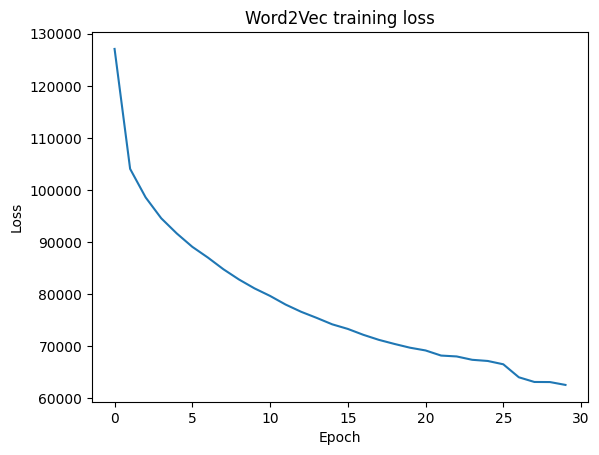

In [7]:
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
import matplotlib.pyplot as plt

class LossLogger(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.prev_loss = 0
        self.losses = []

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss() - self.prev_loss
        self.prev_loss = model.get_latest_training_loss()
        self.losses.append(loss)
        print(f'Epoch {self.epoch}: loss = {loss:.2f}')
        self.epoch += 1

sentences = df['tokens'].tolist()
logger = LossLogger()

w2v = Word2Vec(
    sentences,
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
    epochs=30,
    compute_loss=True,
    callbacks=[logger],
)

print(f'\nРазмер словаря: {len(w2v.wv)}')

plt.plot(logger.losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Word2Vec training loss')
plt.show()


In [8]:
test_words = ['вкусный', 'ужасный', 'официант', 'еда']

for word in test_words:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=5)
        print(f'\n"{word}":')
        for w, score in similar:
            print(f'  {w:20s} {score:.3f}')
    else:
        print(f'\n"{word}" не найдено в словаре')



"вкусный":
  восхитительный       0.650
  отменный             0.648
  качественный         0.622
  впечатлить           0.587
  вкусно               0.556

"ужасный":
  отвратительный       0.812
  ужас                 0.705
  безобразный          0.691
  хромать              0.637
  нуль                 0.636

"официант":
  официантка           0.741
  персонал             0.558
  мальчик              0.538
  ненавязчивый         0.535
  незаметный           0.529

"еда":
  кухня                0.591
  блюдо                0.506
  потрясающе           0.453
  свежий               0.426
  быстрый              0.420


In [9]:
import numpy as np

def vectorize(tokens, model):
    vectors = [
        model.wv[token] if token in model.wv else np.zeros(model.vector_size)
        for token in tokens
    ]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)



In [10]:
df['vector'] = [vectorize(tokens, w2v) for tokens in df['tokens']]

df[['text', 'tokens', 'vector']].head()

,text,tokens,vector
34000,Самый офигенный клуб в Москве . Таких клубов ...,"[самый, офигенный, клуб, москва, клуб, ещё, по...","[-0.21353220812431195, 0.016645149753724293, -..."
34038,отмечали юбилей своей мамочки . он был 05.09.2...,"[отмечать, юбилей, свой, мамочка, пройти, всё,...","[-0.02432270544404919, -0.2167403204492419, 0...."
34039,"Решил оставить отзыв , пока впечатления еще св...","[решить, оставить, отзыв, пока, впечатление, е...","[0.07162097992647129, -0.024539345488495505, -..."
34040,08.09.12 праздновали в ресторане Palati свадьб...,"[праздновать, ресторан, palati, свадьба, всё, ...","[0.03943413613389616, -0.13509259371673815, -0..."
34041,были в кафе Пушкин 16 сентября . Приводили на...,"[кафе, пушкин, приводить, обед, иностранный, г...","[-0.036705761281592024, 0.03855585628990447, -..."


In [11]:
from sklearn.model_selection import train_test_split

X = np.array(df['vector'].tolist())
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, позитивных: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape}, позитивных: {y_test.mean():.2%}')


Train: (2559, 300), позитивных: 75.69%
Test:  (640, 300), позитивных: 75.62%


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'kNN': KNeighborsClassifier(),
}

print(f'{"Модель":<25} {"F1":>8} {"ROC-AUC":>10}')
print('-' * 45)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test, y_proba)
    print(f'{name:<25} {f1:>8.3f} {auc:>10.3f}')


Модель                          F1    ROC-AUC
---------------------------------------------
Logistic Regression          0.906      0.925
Random Forest                0.889      0.920
Gradient Boosting            0.881      0.927
kNN                          0.892      0.897


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tokens_list = df['tokens'].tolist()
tokens_train, _ = train_test_split(
    tokens_list, test_size=0.2, random_state=42, stratify=y
)

# fit только на трейне — IDF считается без тестовых документов
tfidf = TfidfVectorizer(analyzer=lambda x: x)
tfidf.fit(tokens_train)
tfidf_matrix = tfidf.transform(tokens_list)  # трансформируем весь датасет с train-IDF
feature_names = tfidf.get_feature_names_out()

def vectorize_tfidf(tfidf_row, feature_names, model):
    result = np.zeros(model.vector_size)
    for idx, weight in zip(tfidf_row.tocoo().col, tfidf_row.tocoo().data):
        word = feature_names[idx]
        if word in model.wv:
            result += weight * model.wv[word]
    return result


In [14]:
df['vector_tfidf'] = [
    vectorize_tfidf(tfidf_matrix[i], feature_names, w2v)
    for i in range(tfidf_matrix.shape[0])
]

df[['text', 'vector_tfidf']].head()

,text,vector_tfidf
34000,Самый офигенный клуб в Москве . Таких клубов ...,"[-1.0668090909101458, 0.183405372345002, -0.88..."
34038,отмечали юбилей своей мамочки . он был 05.09.2...,"[-0.005078242322170759, -0.8508720860091981, 0..."
34039,"Решил оставить отзыв , пока впечатления еще св...","[0.6834313354947957, 0.002494796798578419, -0...."
34040,08.09.12 праздновали в ресторане Palati свадьб...,"[0.0661720470834887, -0.6225536272112181, 0.19..."
34041,были в кафе Пушкин 16 сентября . Приводили на...,"[0.02293266020835675, 0.5466756975206335, -0.0..."


In [15]:
X_tfidf = np.array(df['vector_tfidf'].tolist())

X_tfidf_train, X_tfidf_test, y_tfidf_train, y_tfidf_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_tfidf_train.shape}, позитивных: {y_tfidf_train.mean():.2%}')
print(f'Test:  {X_tfidf_test.shape}, позитивных: {y_tfidf_test.mean():.2%}')

Train: (2559, 300), позитивных: 75.69%
Test:  (640, 300), позитивных: 75.62%


In [16]:
models_for_tfidf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'kNN': KNeighborsClassifier(),
}

print(f'{"Модель":<25} {"F1":>8} {"ROC-AUC":>10}')
print('-' * 45)
for name, model in models_for_tfidf.items():
    model.fit(X_tfidf_train, y_tfidf_train)
    y_pred = model.predict(X_tfidf_test)
    y_proba = model.predict_proba(X_tfidf_test)[:, 1]
    f1 = f1_score(y_tfidf_test, y_pred, average='weighted')
    auc = roc_auc_score(y_tfidf_test, y_proba)
    print(f'{name:<25} {f1:>8.3f} {auc:>10.3f}')

Модель                          F1    ROC-AUC
---------------------------------------------
Logistic Regression          0.908      0.931
Random Forest                0.894      0.919
Gradient Boosting            0.890      0.922
kNN                          0.895      0.916


Оба способа векторизации предложений приводят к сопоставимому качеству классификации, но TF-IDF как правило дает небольшой прирост в качестве классификатора. В обоих случаях лучшие результаты при использовании Logistical Regression и Gradient Boosting.

In [17]:
from sklearn.model_selection import GridSearchCV

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid={'C': [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='f1_weighted', n_jobs=-1,
)
lr_grid.fit(X_tfidf_train, y_tfidf_train)
print(f'Logistic Regression лучшие параметры: {lr_grid.best_params_}')
print(f'CV F1: {lr_grid.best_score_:.3f}')

y_pred  = lr_grid.predict(X_tfidf_test)
y_proba = lr_grid.predict_proba(X_tfidf_test)[:, 1]
print(f'Test F1: {f1_score(y_test, y_pred, average="weighted"):.3f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

print()
results = pd.DataFrame(lr_grid.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
results = results.sort_values('mean_test_score', ascending=False)
print(results.to_string(index=False))

Logistic Regression лучшие параметры: {'C': 0.1}
CV F1: 0.906
Test F1: 0.910
Test ROC-AUC: 0.930

     params  mean_test_score  std_test_score
 {'C': 0.1}         0.905709        0.010414
   {'C': 1}         0.902627        0.011886
{'C': 0.01}         0.901462        0.004078
  {'C': 10}         0.896572        0.009779
 {'C': 100}         0.887937        0.010952


In [18]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={
        'n_estimators': [100, 200, 500],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1, 0.2],
    },
    cv=5, scoring='f1_weighted', n_jobs=-1,
)
gb_grid.fit(X_tfidf_train, y_train)
print(f'Gradient Boosting лучшие параметры: {gb_grid.best_params_}')
print(f'CV F1: {gb_grid.best_score_:.3f}')

y_pred  = gb_grid.predict(X_tfidf_test)
y_proba = gb_grid.predict_proba(X_tfidf_test)[:, 1]
print(f'Test F1: {f1_score(y_test, y_pred, average="weighted"):.3f}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}')

print()
results = pd.DataFrame(gb_grid.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
results = results.sort_values('mean_test_score', ascending=False)
print(results.to_string(index=False))

Gradient Boosting лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
CV F1: 0.895
Test F1: 0.886
Test ROC-AUC: 0.926

                                                      params  mean_test_score  std_test_score
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}         0.895227        0.009588
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500}         0.894358        0.007730
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}         0.893916        0.005889
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500}         0.893077        0.011707
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}         0.890652        0.013555
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}         0.890624        0.006483
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}         0.890581        0.013494
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}         0.889810        0.007324
 {'learni

Базовые параметры выбраны достаточно оптимально и для небольших датасетов с хорошо разделимыми данными дают результат, который гиперпараметрами сложно улучшить. Скорее результат можно улучшить с помощью увеличения количества и улучшения качества исходных данных. Возможно качество можно было бы поднять с использованием предобученных эмбеддингов на большом русскоязычном корпусе.

В экспериментах с логистической регрессией перебирался параметр C — сила регуляризации (чем меньше, тем сильнее штраф за сложность модели). Лучший результат получился при C=0.1. Слабая регуляризация (C=100) приводит к переобучению и даёт худший результат; слишком сильная (C=0.01) также немного снижает качество.

В экспериментах с градиентным бустингом перебирались параметры n_estimators — количество деревьев в ансамбле, max_depth — максимальная глубина дерева, learning_rate — скорость обучения. Лучший результат при learning_rate=0.1, max_depth=3, n_estimators=500. Большая глубина дерева на небольшом датасете приводит к переобучению. Больше деревьев при малой глубине улучшает результат.

Небольшой разрыв в качестве между моделями говорит о том, что узкое место — качество эмбеддингов, а не выбор классификатора. Возможно, сказывается также сильный дисбаланс классов (75% позитивных отзывов).